In [1]:
import pandas as pd
file_path = "Data_Train.xlsx"
df = pd.read_excel(file_path)
print("Dataset Shape :", df.shape)
print("\nFirst Five Rows:\n")
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum().sum())
print("\nNumber of Duplicate Rows :")
print(df.duplicated().sum())
# Total number of unique cities in Source and Destination
# Total number of unique cities and airlines
# Source cities
source_cities = df['Source'].nunique()
# Destination cities
destination_cities = df['Destination'].nunique()
# Airlines
total_airlines = df['Airline'].nunique()
print("Total Source Cities :", source_cities)
print("Total Destination Cities :", destination_cities)
print("Total Airlines :", total_airlines)
# Display city names
print("\nSource Cities:")
print(df['Source'].unique())
 
print("\nDestination Cities:")
print(df['Destination'].unique())
# Display airline names
print("\nAirlines:")
print(df['Airline'].unique())
# Total unique cities combining Source and Destination
total_cities = set(df['Source']).union(set(df['Destination']))
print("\nTotal Unique Cities in Dataset :", len(total_cities))
print("Cities List :", total_cities)
 
date_col = pd.to_datetime(df['Date_of_Journey'], dayfirst=True)
dep_col  = pd.to_datetime(df['Dep_Time'])
arr_col  = pd.to_datetime(df['Arrival_Time'])
df['Journey_Day']       = date_col.dt.day
df['Journey_Month']     = date_col.dt.month
df['Journey_DayOfWeek'] = date_col.dt.dayofweek
df['Is_Weekend']        = (date_col.dt.dayofweek >= 5).astype(int)
 
df['Dep_Hour']          = dep_col.dt.hour
df['Dep_Minute']        = dep_col.dt.minute
df['Arrival_Hour']      = arr_col.dt.hour
df['Arrival_Minute']    = arr_col.dt.minute
df['Dep_Hour']      = dep_col.dt.hour // 6   # 0=Night,1=Morning,2=Afternoon,3=Evening
 


def duration_to_minutes(d):
    d = str(d).strip()
    hours   = int(d.split('h')[0].strip()) if 'h' in d else 0
    minutes = int(d.split('h')[-1].replace('m','').strip()) if 'm' in d else 0
    return hours * 60 + minutes
 
df['Duration_Minutes'] = df['Duration'].apply(duration_to_minutes)
df['Num_Stops_Route']  = df['Route'].apply(lambda x: str(x).count('→'))
 
stop_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Stops'] = df['Total_Stops'].map(stop_map)
 
print(df.head())
 


Dataset Shape : (10683, 11)

First Five Rows:

       Airline Date_of_Journey    Source Destination                  Route  \
0       IndiGo      24/03/2019  Banglore   New Delhi              BLR → DEL   
1    Air India       1/05/2019   Kolkata    Banglore  CCU → IXR → BBI → BLR   
2  Jet Airways       9/06/2019     Delhi      Cochin  DEL → LKO → BOM → COK   
3       IndiGo      12/05/2019   Kolkata    Banglore        CCU → NAG → BLR   
4       IndiGo      01/03/2019  Banglore   New Delhi        BLR → NAG → DEL   

  Dep_Time  Arrival_Time Duration Total_Stops Additional_Info  Price  
0    22:20  01:10 22 Mar   2h 50m    non-stop         No info   3897  
1    05:50         13:15   7h 25m     2 stops         No info   7662  
2    09:25  04:25 10 Jun      19h     2 stops         No info  13882  
3    18:05         23:30   5h 25m      1 stop         No info   6218  
4    16:50         21:35   4h 45m      1 stop         No info  13302  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10

C:\Users\Bharath Kumar Reddy\AppData\Local\Temp\ipykernel_14696\4093396228.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dep_col  = pd.to_datetime(df['Dep_Time'])
C:\Users\Bharath Kumar Reddy\AppData\Local\Temp\ipykernel_14696\4093396228.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  arr_col  = pd.to_datetime(df['Arrival_Time'])


       Airline Date_of_Journey    Source Destination                  Route  \
0       IndiGo      24/03/2019  Banglore   New Delhi              BLR → DEL   
1    Air India       1/05/2019   Kolkata    Banglore  CCU → IXR → BBI → BLR   
2  Jet Airways       9/06/2019     Delhi      Cochin  DEL → LKO → BOM → COK   
3       IndiGo      12/05/2019   Kolkata    Banglore        CCU → NAG → BLR   
4       IndiGo      01/03/2019  Banglore   New Delhi        BLR → NAG → DEL   

  Dep_Time  Arrival_Time Duration Total_Stops Additional_Info  ...  \
0    22:20  01:10 22 Mar   2h 50m    non-stop         No info  ...   
1    05:50         13:15   7h 25m     2 stops         No info  ...   
2    09:25  04:25 10 Jun      19h     2 stops         No info  ...   
3    18:05         23:30   5h 25m      1 stop         No info  ...   
4    16:50         21:35   4h 45m      1 stop         No info  ...   

   Journey_Month  Journey_DayOfWeek  Is_Weekend  Dep_Hour  Dep_Minute  \
0              3               

In [2]:
import pandas as pd
 
# =========================================================
# REQUIRED COLUMNS
# =========================================================
 
required_columns = [
    "Airline",
    "Source",
    "Destination",
    "Journey_Day",
    "Journey_Month",
            
    "Dep_Hour",
    "Arrival_Hour",
    "Duration_Minutes",
    "Total_Stops",
    "Price"
]
 
# =========================================================
# KEEP ONLY REQUIRED COLUMNS
# =========================================================
 
df = df[required_columns]
 
# =========================================================
# CLEAN TOTAL_STOPS COLUMN
# =========================================================
 
# Convert column to string
df["Total_Stops"] = df["Total_Stops"].astype(str)
 
# Extract numeric values only
# Example:
# "2 stops" -> 2
# "1 stop"  -> 1
# "non-stop" -> NaN
df["Total_Stops"] = df["Total_Stops"].str.extract(r'(\d+)')
 
# Replace NaN values with 0
# (non-stop flights become 0)
df["Total_Stops"] = df["Total_Stops"].fillna(0)
 
# Convert to integer
df["Total_Stops"] = df["Total_Stops"].astype(int)
 
# =========================================================
# CHECK DATATYPES
# =========================================================
 
print("\nData Types:\n")
print(df.dtypes)
 



Data Types:

Airline             object
Source              object
Destination         object
Journey_Day          int32
Journey_Month        int32
Dep_Hour             int32
Arrival_Hour         int32
Duration_Minutes     int64
Total_Stops          int64
Price                int64
dtype: object



Dataset Preview:

       Airline    Source Destination  Journey_Day  Journey_Month  Dep_Hour  \
0       IndiGo  Banglore   New Delhi           24              3         3   
1    Air India   Kolkata    Banglore            1              5         0   
2  Jet Airways     Delhi      Cochin            9              6         1   
3       IndiGo   Kolkata    Banglore           12              5         3   
4       IndiGo  Banglore   New Delhi            1              3         2   

   Arrival_Hour  Duration_Minutes  Total_Stops  Price  
0             1               170            0   3897  
1            13               445            2   7662  
2             4              1140            2  13882  
3            23               325            1   6218  
4            21               285            1  13302  

Final Dataset Shape : (10683, 10)

Airline Value Counts:

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                

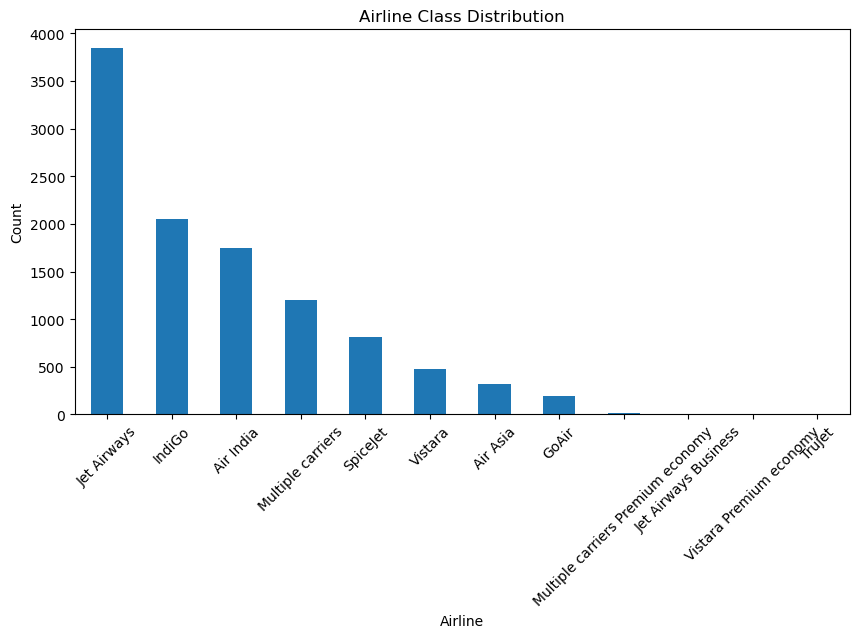


Missing Values:

Airline             0
Source              0
Destination         0
Journey_Day         0
Journey_Month       0
Dep_Hour            0
Arrival_Hour        0
Duration_Minutes    0
Total_Stops         0
Price               0
dtype: int64

Duplicate Rows:

0


In [3]:
# =========================================================
# DISPLAY DATASET
# =========================================================
 
print("\nDataset Preview:\n")
print(df.head())
 
# =========================================================
# DATASET SHAPE
# =========================================================
 
print("\nFinal Dataset Shape :", df.shape)
 
import matplotlib.pyplot as plt
 
# -----------------------------
# AIRLINE CLASS DISTRIBUTION
# -----------------------------
print("\nAirline Value Counts:\n")
print(df["Airline"].value_counts())
 
plt.figure(figsize=(10,5))
 
df["Airline"].value_counts().plot(kind='bar')
 
plt.title("Airline Class Distribution")
plt.xlabel("Airline")
plt.ylabel("Count")
 
plt.xticks(rotation=45)
 
plt.show()
 
 
df.dropna(inplace=True)
print("\nMissing Values:\n")
 
print(df.isnull().sum())
 
  
df.drop_duplicates(inplace=True)
print("\nDuplicate Rows:\n")
print(df.duplicated().sum())
 
numeric_columns = [
    "Journey_Day",
    "Journey_Month",
    "Dep_Hour",
    "Arrival_Hour",
    "Duration_Minutes",
    "Total_Stops",
    "Price"
]


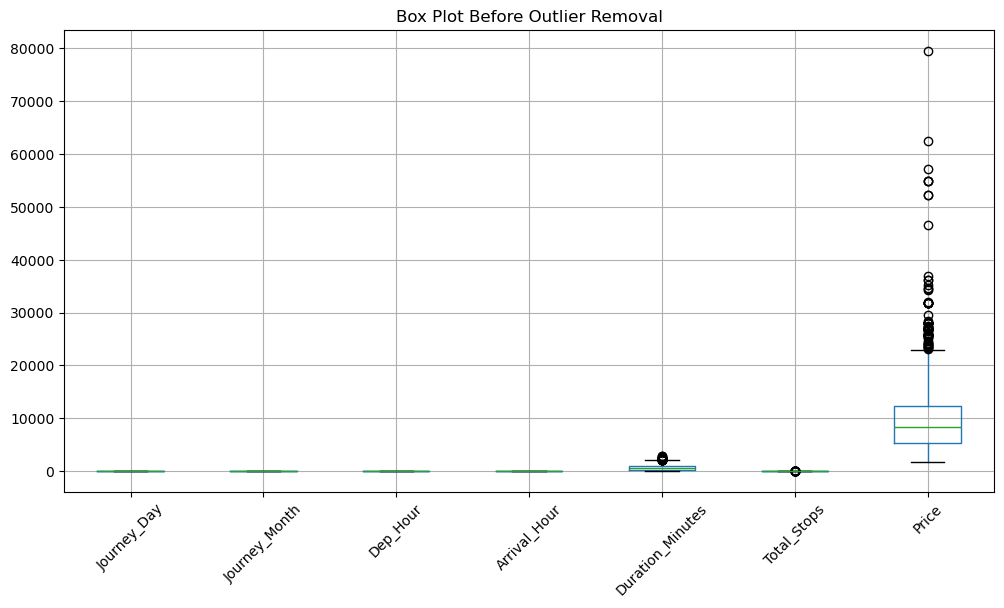

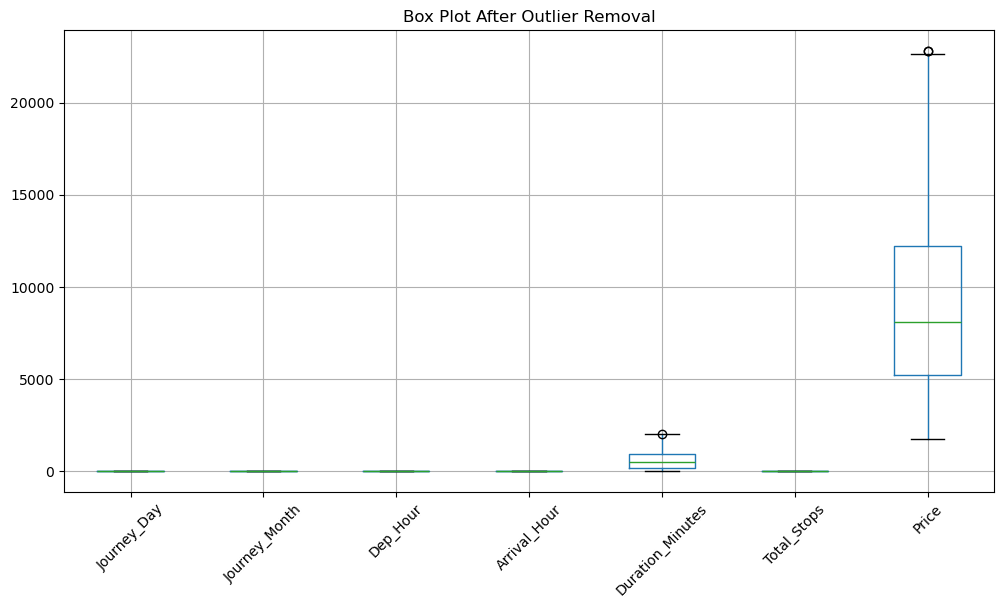


Dataset After Preprocessing:

       Airline    Source Destination  Journey_Day  Journey_Month  Dep_Hour  \
0       IndiGo  Banglore   New Delhi           24              3         3   
1    Air India   Kolkata    Banglore            1              5         0   
2  Jet Airways     Delhi      Cochin            9              6         1   
3       IndiGo   Kolkata    Banglore           12              5         3   
4       IndiGo  Banglore   New Delhi            1              3         2   

   Arrival_Hour  Duration_Minutes  Total_Stops  Price  
0             1               170            0   3897  
1            13               445            2   7662  
2             4              1140            2  13882  
3            23               325            1   6218  
4            21               285            1  13302  
       Airline    Source Destination  Journey_Day  Journey_Month  Dep_Hour  \
0       IndiGo  Banglore   New Delhi           24              3         3   
1    Air

In [4]:
import matplotlib.pyplot as plt
 
# =========================
# NUMERIC COLUMNS
# =========================
 
numeric_columns = [
 
    "Journey_Day",
    "Journey_Month",
    "Dep_Hour",
    "Arrival_Hour",
    "Duration_Minutes",
    "Total_Stops",
    "Price"
]
 
# =========================
# BOX PLOT BEFORE OUTLIER REMOVAL
# =========================
 
plt.figure(figsize=(12,6))
 
df[numeric_columns].boxplot()
 
plt.title("Box Plot Before Outlier Removal")
 
plt.xticks(rotation=45)
 
plt.show()
 
# =========================
# OUTLIER REMOVAL USING IQR
# =========================
 
for column in numeric_columns:
 
    Q1 = df[column].quantile(0.25)
 
    Q3 = df[column].quantile(0.75)
 
    IQR = Q3 - Q1
 
    lower_limit = Q1 - 1.5 * IQR
 
    upper_limit = Q3 + 1.5 * IQR
 
    df = df[
        (df[column] >= lower_limit) &
        (df[column] <= upper_limit)
    ]
 
 
 
# =========================
# BOX PLOT AFTER OUTLIER REMOVAL
# =========================
 
plt.figure(figsize=(12,6))
 
df[numeric_columns].boxplot()
 
plt.title("Box Plot After Outlier Removal")
 
plt.xticks(rotation=45)
 
plt.show()


print("\nDataset After Preprocessing:\n")
 
print(df.head())
 
import pandas as pd
import matplotlib.pyplot as plt
print(df.head())
 


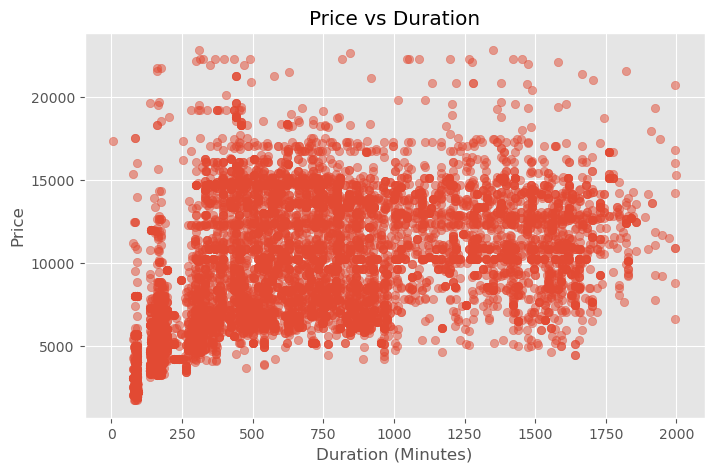

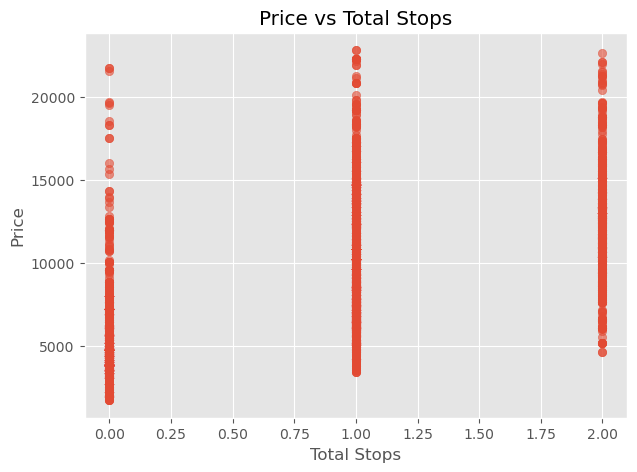

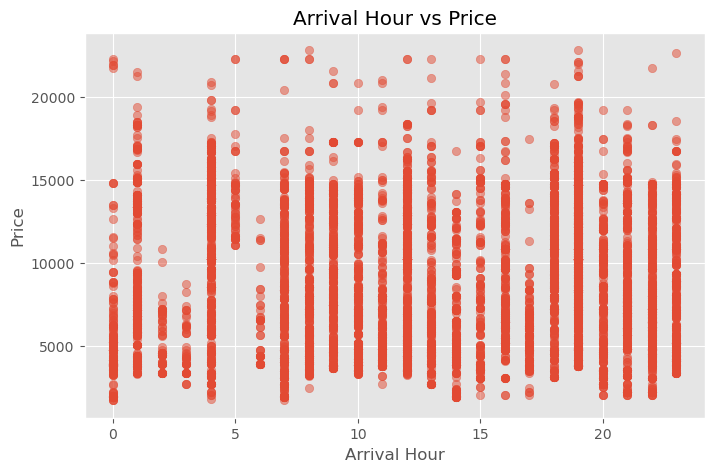

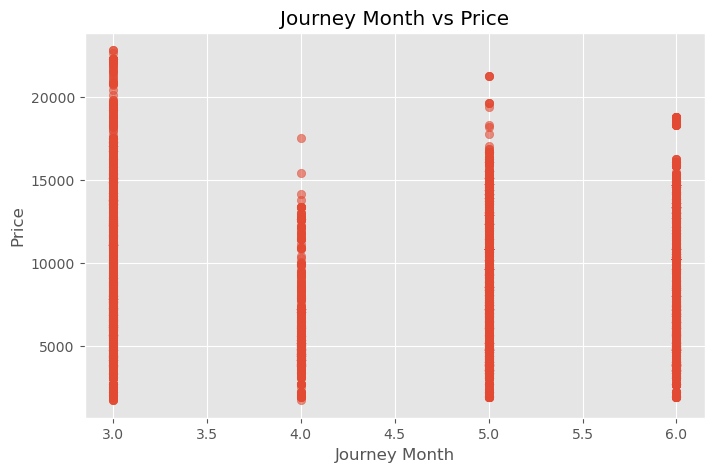

In [5]:
# ================= STYLE =================
plt.style.use('ggplot')
 
# =========================================================
# 1. PRICE vs DURATION
# =========================================================
plt.figure(figsize=(8,5))
plt.scatter(df['Duration_Minutes'],
            df['Price'],
            alpha=0.5)
 
plt.xlabel("Duration (Minutes)")
plt.ylabel("Price")
plt.title("Price vs Duration")
plt.grid(True)
plt.show()
 
 
# =========================================================
# 2. PRICE vs TOTAL STOPS
# =========================================================
plt.figure(figsize=(7,5))
plt.scatter(df['Total_Stops'],
            df['Price'],
            alpha=0.6)
 
plt.xlabel("Total Stops")
plt.ylabel("Price")
plt.title("Price vs Total Stops")
plt.grid(True)
plt.show()
 
# =========================================================
# 3. ARRIVAL HOUR vs PRICE
# =========================================================
plt.figure(figsize=(8,5))
plt.scatter(df['Arrival_Hour'],
            df['Price'],
            alpha=0.5)
 
plt.xlabel("Arrival Hour")
plt.ylabel("Price")
plt.title("Arrival Hour vs Price")
plt.grid(True)
plt.show()
 
# =========================================================
# 4. JOURNEY MONTH vs PRICE
# =========================================================
plt.figure(figsize=(8,5))
plt.scatter(df['Journey_Month'],
            df['Price'],
            alpha=0.6)
 
plt.xlabel("Journey Month")
plt.ylabel("Price")
plt.title("Journey Month vs Price")
plt.grid(True)
plt.show()



Dataset After Encoding:

   Journey_Day  Journey_Month  Dep_Hour  Arrival_Hour  Duration_Minutes  \
0           24              3         3             1               170   
1            1              5         0            13               445   
2            9              6         1             4              1140   
3           12              5         3            23               325   
4            1              3         2            21               285   

   Total_Stops  Price  Airline_Air Asia  Airline_Air India  Airline_GoAir  \
0            0   3897                 0                  0              0   
1            2   7662                 0                  1              0   
2            2  13882                 0                  0              0   
3            1   6218                 0                  0              0   
4            1  13302                 0                  0              0   

   ...  Source_Chennai  Source_Delhi  Source_Kolkata  Source

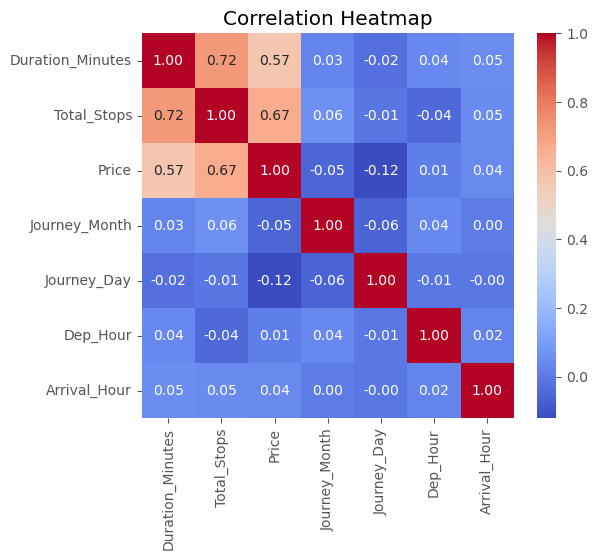

In [6]:
# One-Hot Encoding for first 3 categorical columns
df = pd.get_dummies(
    df,
    columns=["Airline", "Source", "Destination"],
    drop_first=False
)
 
# Convert True/False into 0/1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
 
# Display dataset
print("\nDataset After Encoding:\n")
 
print(df.head())
 
import matplotlib.pyplot as plt
import seaborn as sns
 
# Select required columns
selected_features = [
    "Duration_Minutes",
    "Total_Stops",
    "Price",
    "Journey_Month",
    "Journey_Day",
    "Dep_Hour",
    "Arrival_Hour"
]
 
# Correlation matrix
correlation_matrix = df[selected_features].corr()
 
# Heatmap
plt.figure(figsize=(6,5))
 
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
 
plt.title("Correlation Heatmap")
 
plt.show()
 


In [9]:
import numpy as np
# =========================
# FEATURE ENGINEERING
# =========================
 
# 1. Duration in Hours
df["Duration_Hours"] = df["Duration_Minutes"] / 60
 
 
# 2. Direct Flight Feature
df["Is_Direct_Flight"] = df["Total_Stops"].apply(
    lambda x: 1 if x == 0 else 0
)
 
# 3. Total Travel Intensity
df["Travel_Intensity"] = (
    df["Duration_Minutes"] *
    (df["Total_Stops"] + 1)
)
 
 
# 4. Log Transformation of Price
df["Log_Price"] = np.log1p(df["Price"])
 
 
# =========================
# DISPLAY DATASET
# =========================
 
print("\nDataset After Feature Engineering:\n")
 
print(df.head())



Dataset After Feature Engineering:

   Journey_Day  Journey_Month  Dep_Hour  Arrival_Hour  Duration_Minutes  \
0           24              3         3             1               170   
1            1              5         0            13               445   
2            9              6         1             4              1140   
3           12              5         3            23               325   
4            1              3         2            21               285   

   Total_Stops  Price  Airline_Air Asia  Airline_Air India  Airline_GoAir  \
0            0   3897                 0                  0              0   
1            2   7662                 0                  1              0   
2            2  13882                 0                  0              0   
3            1   6218                 0                  0              0   
4            1  13302                 0                  0              0   

   ...  Destination_Banglore  Destination_Cochin 

In [13]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 7.8 MB/s eta 0:00:07
   -- ------------------------------------- 3.1/48.9 MB 9.1 MB/s eta 0:00:06
   ---- ----------------------------------- 5.5/48.9 MB 10.0 MB/s eta 0:00:05
   ------ --------------------------------- 8.1/48.9 MB 10.8 MB/s eta 0:00:04
   -------- ------------------------------- 10.5/48.9 MB 10.7 MB/s eta 0:00:04
   ---------- ----------------------------- 13.4/48.9 MB 11.2 MB/s eta 0:00:04
   ------------ --------------------------- 15.5/48.9 MB 11.0 MB/s eta 0:00:04
   -------------- ------------------------- 17.3/48.9 MB 10.8 MB/s eta 0:00:03
   ---------------- ----------------------- 19.9/48.9 MB 10.9 MB/s eta 0:00:03
   ------------------ --------------------- 22.3/48.9 MB 11.0 MB/s eta 0:00:03
   ------------------- -------------------- 24.1/48.9 MB 10.8 MB/s eta 0:00:03
   -------------------- ------------------- 25.4/48.9 MB 10.3 MB/s 

In [14]:
# =========================
# IMPORT LIBRARIES
# =========================
 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
 
from xgboost import XGBRegressor
 
import numpy as np
import pandas as pd
 


In [15]:
# =========================
# FEATURES AND TARGET
# =========================
 
X = df.drop(["Price"], axis=1)
 
y = df["Price"]
 
# =========================
# TRAIN TEST SPLIT
# =========================
 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [16]:
# =========================
# MODELS
# =========================
 
models = {
 
    "Linear Regression":
        LinearRegression(),
 
    "Decision Tree":
        DecisionTreeRegressor(random_state=42),
 
    "Random Forest":
        RandomForestRegressor(
            n_estimators=500,
            random_state=42
        ),
 
    "KNN":
        KNeighborsRegressor(),
 
    "XGBoost":
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.1,
            random_state=42
        )
}
 


In [17]:
# =========================
# TRAINING & EVALUATION
# =========================
 
results = []
 
for name, model in models.items():
 
    # Train model
    model.fit(X_train, y_train)
 
    # Prediction
    y_pred = model.predict(X_test)
 
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
 
    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )
 
    r2 = r2_score(y_test, y_pred)
 
    accuracy = r2 * 100
 
    # Store results
    results.append([
        name,
        mae,
        rmse,
        r2,
        accuracy
    ])
 


In [19]:
# =========================
# RESULTS TABLE
# =========================
 
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score",
        "Accuracy (%)"
    ]
)
 
print("\nMODEL COMPARISON\n")
 
print(results_df)



MODEL COMPARISON

               Model          MAE         RMSE  R2 Score  Accuracy (%)
0  Linear Regression   632.123912   877.316465  0.953459     95.345883
1      Decision Tree     1.477539     6.844392  0.999997     99.999717
2      Random Forest     1.378797     6.419641  0.999998     99.999751
3                KNN  1676.519531  2459.203095  0.634310     63.430963
4            XGBoost    13.443352    51.792597  0.999838     99.983782
